# 04. Implementacja metod i porownanie wynikow

**Etap z planu pracy:** implementacja wybranych metod i porownanie wynikow.

Notebook wykonuje testy H1-H2 oraz benchmark H3 na oczyszczonej bazie. Wyniki sa zapisywane do `outputs/czysta_baza`.


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "database").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "database" / "NajnowszaWersjaBazy1205_prepared.csv"
RAW_DATA_PATH = PROJECT_ROOT / "database" / "NajnowszaWersjaBazy1205.csv"
METADATA_PATH = PROJECT_ROOT / "outputs" / "prepared_dataset_metadata.json"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "czysta_baza"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
print("Prepared data exists:", DATA_PATH.exists())
print("Output dir:", OUTPUT_DIR)

assert DATA_PATH.exists(), f"Brakuje pliku z przygotowana baza: {DATA_PATH}"


PROJECT_ROOT: C:\Users\szymon\projekt_reddit
DATA_PATH: C:\Users\szymon\projekt_reddit\database\NajnowszaWersjaBazy1205_prepared.csv
Prepared data exists: True
Output dir: C:\Users\szymon\projekt_reddit\outputs\czysta_baza


In [2]:
import time

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

from src.reddit_pbl.columns import COGNITIVE_COMPLEXITY_FEATURES
from src.reddit_pbl.statistics import compare_groups, point_biserial

RANDOM_STATE = 42
df = pd.read_csv(DATA_PATH, parse_dates=["TIMESTAMP"])

with open(METADATA_PATH, "r", encoding="utf-8") as file:
    metadata = json.load(file)

print("Rows:", df.shape[0], "Columns:", df.shape[1])
print(df.groupby("split_chronological")["is_negative_link"].agg(["size", "sum", "mean"]))


Rows: 49918 Columns: 106
                      size   sum   mean
split_chronological                    
test                  9984   680 0.0681
train                39934  3174 0.0795


## H1. Eskalacja emocjonalna

Testujemy, czy flaga wysokiego poprzedniego anger w oknie 24h zwieksza odsetek linkow negatywnych.


In [3]:
h1_table = pd.crosstab(df["high_previous_anger_24h"].astype(bool), df["is_negative_link"].astype(int))
h1_table = h1_table.reindex(index=[False, True], columns=[0, 1], fill_value=0)

odds_ratio, fisher_p = stats.fisher_exact(h1_table.to_numpy())
chi2, chi2_p, _, _ = stats.chi2_contingency(h1_table.to_numpy())

h1_rates = (
    df.groupby(df["high_previous_anger_24h"].astype(bool))["is_negative_link"]
    .agg(rows="size", negative_links="sum", negative_rate="mean")
    .rename_axis("high_previous_anger_24h")
    .reset_index()
)
anger_threshold = df.loc[df["prev_pair_interactions_24h"] > 0, "prev_pair_mean_anger_24h"].quantile(0.75)
low_rate = float(h1_rates.loc[h1_rates["high_previous_anger_24h"] == False, "negative_rate"].iloc[0])
high_rate = float(h1_rates.loc[h1_rates["high_previous_anger_24h"] == True, "negative_rate"].iloc[0])

h1_result = h1_rates.assign(
    anger_threshold_q75=anger_threshold,
    negative_rate_delta_high_minus_other=high_rate - low_rate,
    odds_ratio_high_vs_other=odds_ratio,
    fisher_p_value=fisher_p,
    chi2=chi2,
    chi2_p_value=chi2_p,
)

display(h1_table)
display(h1_result)
h1_result.to_csv(OUTPUT_DIR / "04_h1_emotional_escalation.csv", index=False)


is_negative_link,0,1
high_previous_anger_24h,,
False,45949,3845
True,115,9


,high_previous_anger_24h,rows,negative_links,negative_rate,anger_threshold_q75,negative_rate_delta_high_minus_other,odds_ratio_high_vs_other,fisher_p_value,chi2,chi2_p_value
0,False,49794,3845,0.0772,0.0064,-0.0046,0.9352,1.0000,0.0006,0.9802
1,True,124,9,0.0726,0.0064,-0.0046,0.9352,1.0000,0.0006,0.9802


## H2. Zlozonosc poznawcza

Porownujemy teksty linkow negatywnych i pozytywnych dla cech wskazanych w metadanych przygotowanego zbioru.


,feature,negative_n,positive_n,negative_mean,positive_mean,difference_negative_minus_positive,negative_median,positive_median,cohens_d_negative_minus_positive,point_biserial_negative,mannwhitney_u,mannwhitney_p_value
2,Automated readability index,3854,46064,20.0715,21.5987,-1.5272,18.3295,18.5775,-0.1217,-0.0263,85139348.5000,0.0000
5,Average number of words per sentence,3854,46064,20.6283,23.0728,-2.4445,18.3333,18.4167,-0.1124,-0.0235,88506757.0000,0.7635
0,Average word length,3854,46064,5.3378,5.3320,0.0058,4.9662,4.9532,0.0044,0.0011,89823349.5000,0.2183
4,Number of words,3854,46064,276.6056,228.6261,47.9795,139.0000,104.0000,0.1288,0.0362,97562599.0000,0.0000
1,LIWC_Conj,3854,46064,0.0444,0.0405,0.0038,0.0478,0.0429,0.1386,0.0365,95900460.5000,0.0000
3,LIWC_CogMech,3854,46064,0.1248,0.1161,0.0087,0.1349,0.1250,0.1412,0.0372,96374643.5000,0.0000


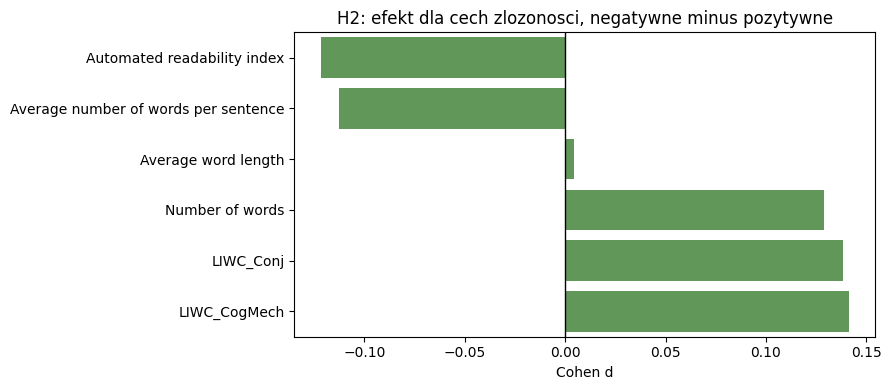

In [4]:
h2_rows = []
cognitive_features = [column for column in COGNITIVE_COMPLEXITY_FEATURES if column in df.columns]

for feature in cognitive_features:
    comparison = compare_groups(
        df,
        group_col="LINK_SENTIMENT",
        value_col=feature,
        negative_value=-1,
        positive_value=1,
    )
    negative = pd.to_numeric(df.loc[df["LINK_SENTIMENT"] == -1, feature], errors="coerce").dropna()
    positive = pd.to_numeric(df.loc[df["LINK_SENTIMENT"] == 1, feature], errors="coerce").dropna()
    pooled_std = np.sqrt((negative.var(ddof=1) + positive.var(ddof=1)) / 2)
    mann = stats.mannwhitneyu(negative, positive, alternative="two-sided")
    h2_rows.append(
        {
            "feature": feature,
            **comparison,
            "cohens_d_negative_minus_positive": comparison["difference_negative_minus_positive"] / pooled_std if pooled_std else np.nan,
            "point_biserial_negative": point_biserial(df["is_negative_link"], df[feature]),
            "mannwhitney_u": mann.statistic,
            "mannwhitney_p_value": mann.pvalue,
        }
    )

h2_result = pd.DataFrame(h2_rows).sort_values("cohens_d_negative_minus_positive")
display(h2_result)
h2_result.to_csv(OUTPUT_DIR / "04_h2_cognitive_complexity.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=h2_result,
    y="feature",
    x="cohens_d_negative_minus_positive",
    ax=ax,
    color="#59a14f",
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("H2: efekt dla cech zlozonosci, negatywne minus pozytywne")
ax.set_xlabel("Cohen d")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "04_h2_cognitive_complexity_effects.png", dpi=160)


## H3. Benchmark multimodalny

Trenujemy modele na czesci `train` i oceniamy na pozniejszej czesci `test`. Najwazniejsza metryka to `negative_f1`, poniewaz klasa negatywna jest mniejszosciowa.


In [5]:
def metrics_row(name: str, y_true: pd.Series, y_pred: np.ndarray, train_seconds: float | None = None) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "negative_precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "negative_recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "negative_f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "train_seconds": train_seconds,
    }


train = df[df["split_chronological"] == "train"].copy()
test = df[df["split_chronological"] == "test"].copy()
y_train = train["is_negative_link"].astype(int)
y_test = test["is_negative_link"].astype(int)

numeric_features = [column for column in metadata["numeric_features"] if column in df.columns]
indicator_features = [column for column in metadata["indicator_features"] if column in df.columns]
hf_features = [column for column in ["Content_Sentiment", "Content_Score"] if column in df.columns]
numeric_no_hf = [column for column in numeric_features + indicator_features if column not in hf_features]
numeric_with_hf = list(dict.fromkeys(numeric_no_hf + hf_features))

numeric_preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

tree_preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

models = {
    "Dummy most frequent": DummyClassifier(strategy="most_frequent"),
    "TF-IDF word 1-2 + Logistic Regression balanced": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, min_df=2, ngram_range=(1, 2), sublinear_tf=True)),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "TF-IDF word 1-2 + Linear SVC balanced": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, min_df=2, ngram_range=(1, 2), sublinear_tf=True)),
        ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Properties + Logistic Regression balanced": Pipeline([
        ("prep", ColumnTransformer([("num", numeric_preprocess, numeric_no_hf)])),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Properties + Random Forest balanced": Pipeline([
        ("prep", ColumnTransformer([("num", tree_preprocess, numeric_no_hf)])),
        ("clf", RandomForestClassifier(
            n_estimators=250,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
    "HF sentiment columns + Logistic Regression balanced": Pipeline([
        ("prep", ColumnTransformer([("hf", numeric_preprocess, hf_features)])),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "HF sentiment columns + Properties + Logistic Regression balanced": Pipeline([
        ("prep", ColumnTransformer([("num", numeric_preprocess, numeric_with_hf)])),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "TF-IDF + Properties + HF columns + Logistic Regression balanced": Pipeline([
        ("prep", ColumnTransformer([
            ("text", TfidfVectorizer(max_features=30000, min_df=2, ngram_range=(1, 2), sublinear_tf=True), "combined_text"),
            ("num", numeric_preprocess, numeric_with_hf),
        ])),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
}

benchmark_rows = []

rule_pred = test["high_previous_anger_24h"].astype(int).to_numpy()
benchmark_rows.append(metrics_row("Rule: high previous anger -> negative", y_test, rule_pred, train_seconds=0.0))

hf_direct_pred = (test["Content_Sentiment"] == -1).astype(int).to_numpy()
benchmark_rows.append(metrics_row("HF Content_Sentiment direct baseline", y_test, hf_direct_pred, train_seconds=0.0))

for name, model in models.items():
    start = time.perf_counter()
    if name.startswith("TF-IDF word"):
        model.fit(train["combined_text"], y_train)
        prediction = model.predict(test["combined_text"])
    else:
        model.fit(train, y_train)
        prediction = model.predict(test)
    elapsed = time.perf_counter() - start
    benchmark_rows.append(metrics_row(name, y_test, prediction, train_seconds=elapsed))
    print(f"Finished: {name} ({elapsed:.1f}s)")

h3_benchmark = pd.DataFrame(benchmark_rows).sort_values(["negative_f1", "macro_f1"], ascending=False)
display(h3_benchmark)
h3_benchmark.to_csv(OUTPUT_DIR / "04_h3_multimodal_benchmark.csv", index=False)


Finished: Dummy most frequent (0.0s)
Finished: TF-IDF word 1-2 + Logistic Regression balanced (40.3s)
Finished: TF-IDF word 1-2 + Linear SVC balanced (44.9s)
Finished: Properties + Logistic Regression balanced (2.4s)
Finished: Properties + Random Forest balanced (12.5s)
Finished: HF sentiment columns + Logistic Regression balanced (0.0s)
Finished: HF sentiment columns + Properties + Logistic Regression balanced (2.4s)
Finished: TF-IDF + Properties + HF columns + Logistic Regression balanced (85.8s)


,model,accuracy,macro_f1,weighted_f1,negative_precision,negative_recall,negative_f1,tn,fp,fn,tp,train_seconds
3,TF-IDF word 1-2 + Logistic Regression balanced,0.8562,0.6315,0.8800,0.2493,0.5529,0.3437,8172,1132,304,376,40.3008
9,TF-IDF + Properties + HF columns + Logistic Re...,0.8374,0.6236,0.8687,0.2350,0.6147,0.3400,7943,1361,262,418,85.8432
4,TF-IDF word 1-2 + Linear SVC balanced,0.8975,0.6320,0.9020,0.2916,0.3529,0.3194,8721,583,440,240,44.8955
8,HF sentiment columns + Properties + Logistic R...,0.7290,0.5476,0.7950,0.1603,0.7029,0.2611,6800,2504,202,478,2.3918
5,Properties + Logistic Regression balanced,0.7231,0.5428,0.7908,0.1565,0.6985,0.2557,6744,2560,205,475,2.3966
1,HF Content_Sentiment direct baseline,0.8349,0.5705,0.8616,0.1707,0.3691,0.2335,8085,1219,429,251,0.0000
7,HF sentiment columns + Logistic Regression bal...,0.7008,0.5069,0.7740,0.1209,0.5412,0.1977,6629,2675,312,368,0.0352
6,Properties + Random Forest balanced,0.9322,0.5023,0.9018,0.5600,0.0206,0.0397,9293,11,666,14,12.4704
0,Rule: high previous anger -> negative,0.9290,0.4844,0.8980,0.0606,0.0029,0.0056,9273,31,678,2,0.0000
2,Dummy most frequent,0.9319,0.4824,0.8990,0.0000,0.0000,0.0000,9304,0,680,0,0.0016


Najlepszy model wg F1 klasy negatywnej:


,value
model,TF-IDF word 1-2 + Logistic Regression balanced
accuracy,0.8562
macro_f1,0.6315
weighted_f1,0.8800
negative_precision,0.2493
negative_recall,0.5529
negative_f1,0.3437
tn,8172
fp,1132
fn,304


Czy negative_f1 >= 0.75? False


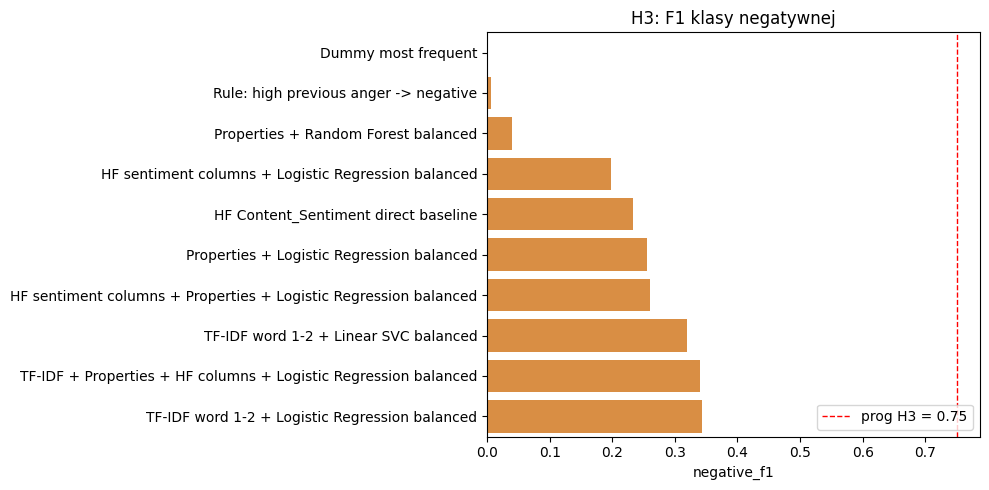

In [6]:
best_model = h3_benchmark.iloc[0]
print("Najlepszy model wg F1 klasy negatywnej:")
display(best_model.to_frame("value"))
print("Czy negative_f1 >= 0.75?", bool(best_model["negative_f1"] >= 0.75))

fig, ax = plt.subplots(figsize=(10, 5))
plot_bench = h3_benchmark.sort_values("negative_f1", ascending=True)
sns.barplot(data=plot_bench, y="model", x="negative_f1", ax=ax, color="#f28e2b")
ax.axvline(0.75, color="red", linestyle="--", linewidth=1, label="prog H3 = 0.75")
ax.set_title("H3: F1 klasy negatywnej")
ax.set_xlabel("negative_f1")
ax.set_ylabel("")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "04_h3_negative_f1_benchmark.png", dpi=160)


In [7]:
rf_name = "Properties + Random Forest balanced"
rf_model = models[rf_name]
if hasattr(rf_model.named_steps["clf"], "feature_importances_"):
    rf_importance = (
        pd.DataFrame({
            "feature": numeric_no_hf,
            "importance": rf_model.named_steps["clf"].feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .head(25)
    )
    display(rf_importance)
    rf_importance.to_csv(OUTPUT_DIR / "04_h3_random_forest_feature_importance.csv", index=False)


,feature,importance
19,Negative sentiment calculated by VADER,0.0473
49,LIWC_Negemo,0.0433
51,LIWC_Anger,0.0370
89,source_previous_links,0.0315
20,Compound sentiment calculated by VADER,0.0281
4,Fraction of uppercase characters,0.0255
2,Fraction of alphabetical characters,0.0245
92,common_neighbors_so_far,0.0212
90,target_previous_links,0.0193
10,Average word length,0.0180


## Rezultat etapu

Wszystkie trzy hipotezy maja policzone tabele wynikowe. Nastepny notebook interpretuje, czy wyniki wspieraja hipotezy, i opisuje ograniczenia badania.
